#hey

In [2]:
from langgraph.graph import START,END, StateGraph
from langchain_ollama import ChatOllama
from typing import TypedDict,Annotated
from langchain_core.messages import HumanMessage,BaseMessage
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph.message import add_messages

In [3]:
model = ChatOllama(
    model="qwen3.5:4b",
    temperature=1
)

In [4]:
class State(TypedDict):
    message: Annotated[list[BaseMessage],add_messages]

In [5]:
def chat_model(state: State):
    message = state['message']
    response = model.invoke(message)
    return {"message": [response]}

In [6]:
graph = StateGraph(State)

graph.add_node("chat_model",chat_model)

graph.add_edge(START, 'chat_model')
graph.add_edge('chat_model',END)

checkpointer = InMemorySaver()
workflow = graph.compile(checkpointer=checkpointer)

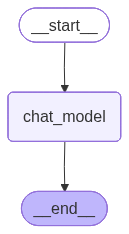

In [7]:
workflow

In [8]:
config = {'configurable':{'thread_id':'1'}}

In [9]:
message = HumanMessage("hey okay!")

initial_state = {
    "message": message
}

result = workflow.invoke(initial_state,config=config)

In [10]:
result

{'message': [HumanMessage(content='hey okay!', additional_kwargs={}, response_metadata={}, id='02236e81-e0d7-465c-a997-70edcc1e8b1a'),
  AIMessage(content="Hey there! 🙌 Sounds good, I'm ready whenever you need me. What’s on your mind?", additional_kwargs={}, response_metadata={'model': 'qwen3.5:4b', 'created_at': '2026-06-18T06:46:57.8355172Z', 'done': True, 'done_reason': 'stop', 'total_duration': 14671593600, 'load_duration': 1365450500, 'prompt_eval_count': 13, 'prompt_eval_duration': 220942000, 'eval_count': 815, 'eval_duration': 12981355000, 'logprobs': None, 'model_name': 'qwen3.5:4b', 'model_provider': 'ollama'}, id='lc_run--019ed97b-64d8-7771-bf93-327ff6f0a9e9-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 815, 'total_tokens': 828})]}

In [11]:
while True:
    user_input = input("Enter Query: ")

    if user_input == '/end':
        break

    message = [HumanMessage(content=user_input)]


    initial_state = {
        "message": message
    }

    for message_chunk, metadata in workflow.stream(initial_state,config=config,stream_mode='messages'):
        if message_chunk:
            print(message_chunk.content,end = "")

Hey there! 👋 How is everything going? Anything exciting on your mind or something I can help you with today?India stands as one of the world’s most fascinating and diverse nations, a country whose history stretches back thousands of years and whose cultural landscape remains vibrant today. Located in South Asia on the Indian Peninsula, this nation is known for its vast geographical terrain that includes the Himalayas to the north, extensive river valleys, rich coastal regions along the Arabian Sea and Bay of Bengal, and numerous island territories including the Andamans and Lakshadweep archipelagoes. Its population hovers around one point two billion people who speak over twenty-one recognized languages in addition to hundreds of mother tongues used daily across different communities throughout its territory. The capital city New Delhi serves as a political hub alongside Mumbai, which holds significant economic power due to its financial district andI apologize for that issue with your

In [12]:
workflow.get_state(config)

StateSnapshot(values={'message': [HumanMessage(content='hey okay!', additional_kwargs={}, response_metadata={}, id='02236e81-e0d7-465c-a997-70edcc1e8b1a'), AIMessage(content="Hey there! 🙌 Sounds good, I'm ready whenever you need me. What’s on your mind?", additional_kwargs={}, response_metadata={'model': 'qwen3.5:4b', 'created_at': '2026-06-18T06:46:57.8355172Z', 'done': True, 'done_reason': 'stop', 'total_duration': 14671593600, 'load_duration': 1365450500, 'prompt_eval_count': 13, 'prompt_eval_duration': 220942000, 'eval_count': 815, 'eval_duration': 12981355000, 'logprobs': None, 'model_name': 'qwen3.5:4b', 'model_provider': 'ollama'}, id='lc_run--019ed97b-64d8-7771-bf93-327ff6f0a9e9-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 815, 'total_tokens': 828}), HumanMessage(content='hey there.', additional_kwargs={}, response_metadata={}, id='0425fb69-f8dc-4641-9010-c027e56f4409'), AIMessage(content='Hey there! 👋 How is everything going? A